<a href="https://colab.research.google.com/github/Shaurya-XD/IPL2022_Analysis/blob/main/IPL2022_DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [4]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


In [5]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 74, Columns: 20


In [6]:
df.isna().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [7]:
match_win = df['match_winner'].value_counts()
match_win

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 0, 'Number of Matches')

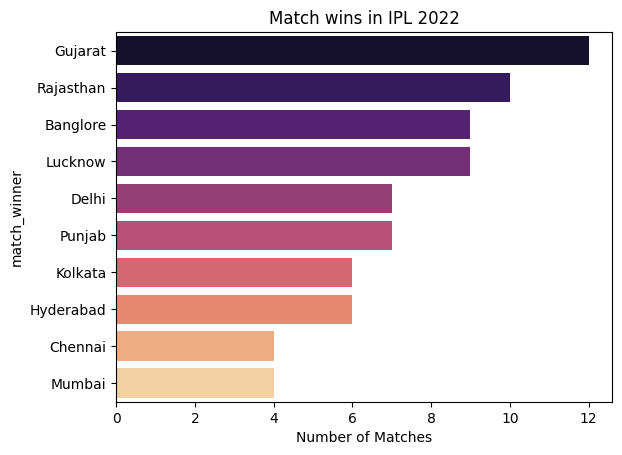

In [8]:
sns.barplot(y=match_win.index, x=match_win.values, palette='magma')
plt.title("Match wins in IPL 2022")
plt.xlabel('Number of Matches')

In [9]:
toss = df['toss_decision'].value_counts()
toss

toss_decision
Field    59
Bat      15
Name: count, dtype: int64

Text(0.5, 0, 'Toss Decision')

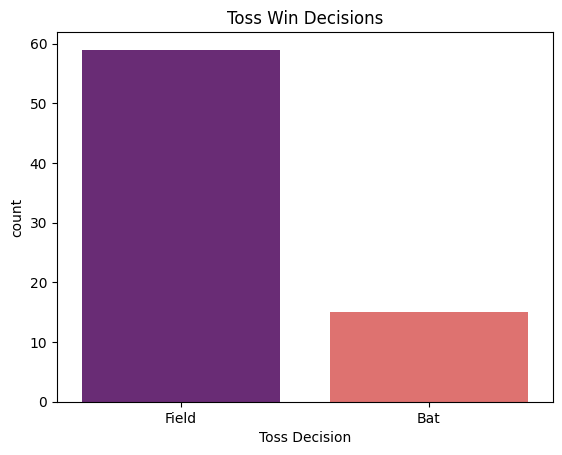

In [10]:
sns.countplot(x = df['toss_decision'], palette='magma')
plt.title("Toss Win Decisions")
plt.xlabel('Toss Decision')

In [11]:
toss_match_win = df['match_winner'] == df['toss_winner']
win_percentage = toss_match_win.sum()/df.shape[0]*100
print(f"Probality that the toss winners won the match: {round(win_percentage, 2)}%")

Probality that the toss winners won the match: 48.65%


Text(0.5, 0, 'Number of Wickets')

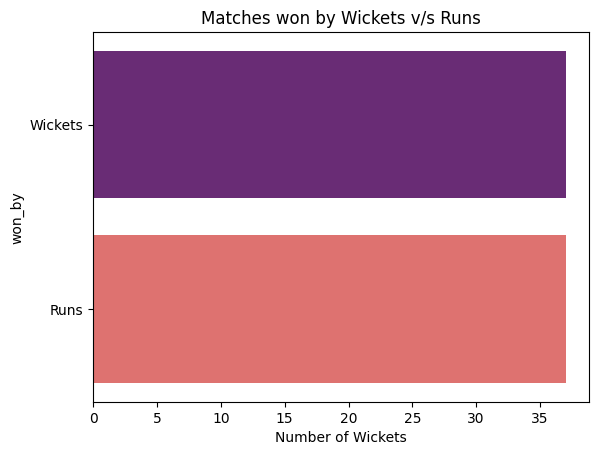

In [12]:
sns.countplot(df['won_by'], palette='magma')
plt.title('Matches won by Wickets v/s Runs')
plt.xlabel('Number of Wickets')

Text(0.5, 0, 'Number of Matches')

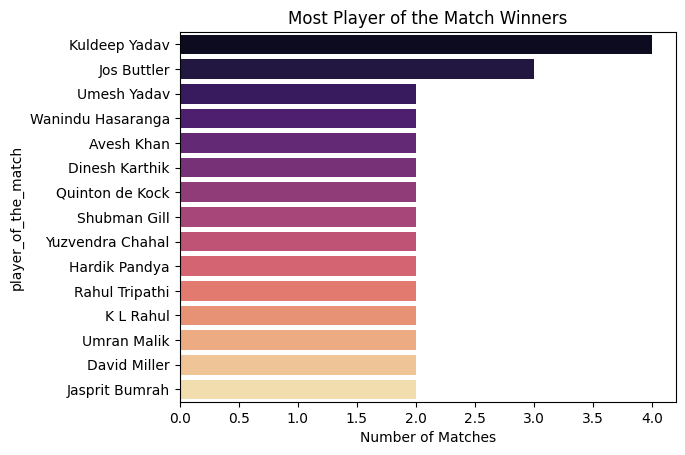

In [13]:
best_player = df['player_of_the_match'].value_counts().head(15)
sns.barplot(y = best_player.index, x = best_player.values, palette='magma')
plt.title('Most Player of the Match Winners')
plt.xlabel('Number of Matches')

Text(0.5, 0, 'Runs')

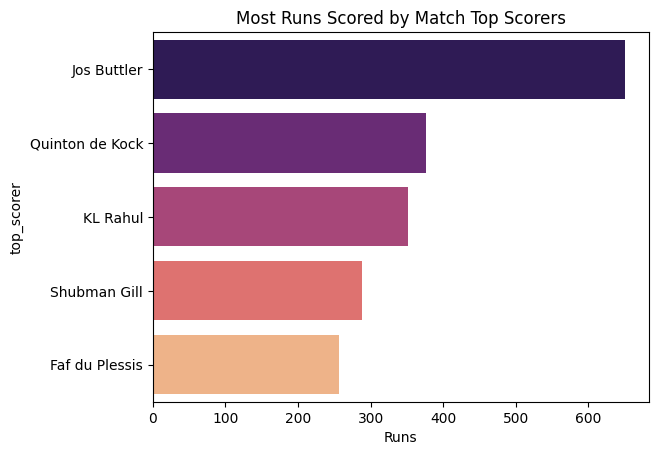

In [14]:
top_scorers = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head()
sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='magma')
plt.title('Most Runs Scored by Match Top Scorers')
plt.xlabel('Runs')

Text(0.5, 0, 'Number of wickets')

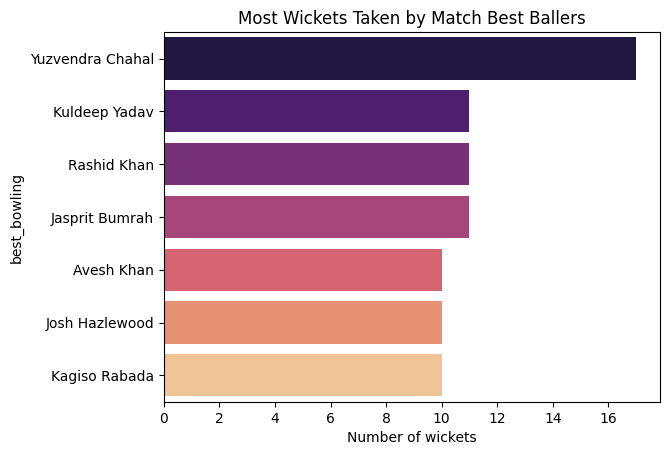

In [16]:
def extract_wickets(txt):
  wic = txt.split("--")[0]
  return wic

df['highest_wickets'] = df['best_bowling_figure'].apply(extract_wickets)
df['highest_wickets'] = df['highest_wickets'].astype(int)

most_wic = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(7)
sns.barplot(x=most_wic.values, y=most_wic.index, palette='magma')
plt.title('Most Wickets Taken by Match Best Ballers')
plt.xlabel('Number of wickets')

<Axes: xlabel='count', ylabel='venue'>

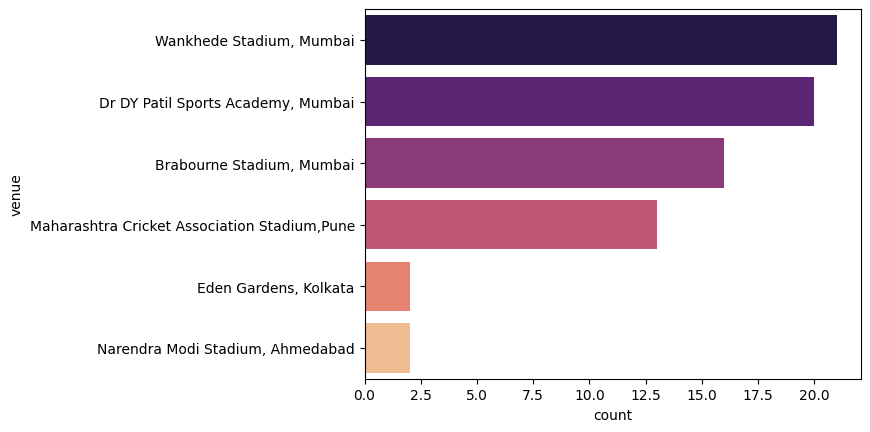

In [23]:
sns.countplot(df['venue'], palette='magma', order=df['venue'].value_counts().index)

Text(0.5, 0, 'Win Margin (Runs)')

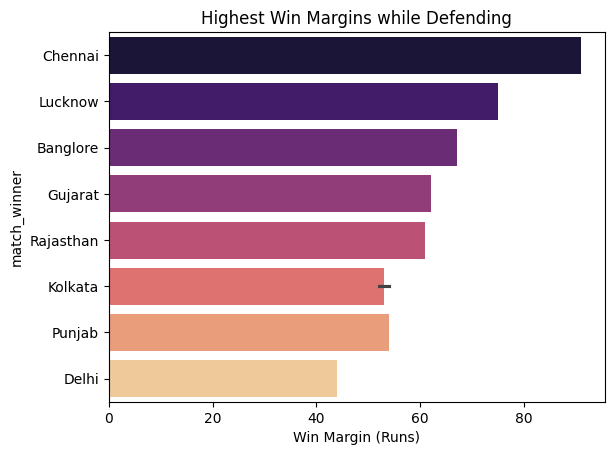

In [43]:
won_runs = df['won_by'].str.lower() == 'runs'
best_defend = df[won_runs].sort_values(by='margin', ascending=False).head(10)
sns.barplot(x=best_defend['margin'], y=best_defend['match_winner'], palette='magma')
plt.title('Highest Win Margins while Defending')
plt.xlabel('Win Margin (Runs)')

In [51]:
most_runs = df['highscore'] == df['highscore'].max()
df[most_runs][['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [54]:
most_runs = df['highest_wickets'] == df['highest_wickets'].max()
df[most_runs][['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
